In [1]:
from pathlib import Path
import sys

# Allow running the notebook from its folder without installing the package.
repo_root = Path.cwd().resolve()
while repo_root.name != "QuPCA" and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Initial tests for the low-complexity QPCA pipeline

This notebook is an exploratory sandbox built around the toy example from *A Low-Complexity Quantum Principal Component Analysis Algorithm*.

It is useful when the goal is to inspect the old prototype step by step rather than to use the package as a black box. The notebook walks through:

- amplitude extraction from the input matrix;
- recovery of the qRAM rotation angles;
- construction of the custom qRAM circuit;
- phase-estimation-based eigenvalue encoding;
- assembly of the full circuit and peak inspection;
- comparison with higher-level Qiskit primitives.

In [2]:
import numpy as np
import itertools

example_matrix = np.array([[1.5, 0.5], [0.5, 1.5]])
# example_matrix = np.dot(np.array([[1.3, 0.35], [0.4, 1.1]]),np.array([[1.3, 0.35], [0.4, 1.1]]).T)
big_example_matrix = np.array([[0, 0, 0, 0], [0, 1, 0, 0], [0, 0, 2, 0], [0, 0, 0, 3]]) #(just remove "big_" to try 4*4)

sum_squares = (example_matrix**2).sum()
input_probabilities = (example_matrix**2/sum_squares).flatten()

print(input_probabilities)

[0.45 0.05 0.05 0.45]


## 1. Reference example and theoretical target

This section fixes the 2x2 matrix used in the paper and states the target quantum output that the rest of the notebook is trying to reproduce.


The code above defines the input matrix and converts it into amplitude probabilities. The formulas below are the ground truth used to judge whether the custom encoding and the later phase-estimation steps are behaving correctly.


As an example, whose quantum state is given by
$$\left|\psi_{A_0}\right\rangle=\frac{3}{\sqrt{20}}|00\rangle+\frac{1}{\sqrt{20}}|01\rangle+\frac{1}{\sqrt{20}}|10\rangle+\frac{3}{\sqrt{20}}|11\rangle .$$

Note that the eigenvalues and the corresponding eigenvectors obtained by classical PCA are given by
$$\lambda_1=2, u_1=[1,1]^T$$
$$\lambda_2=1, u_2=[−1,1]^T.$$

Note: $[1, 0]^T = |0〉$ and $[0, 1]^T = |1〉.$ 

When we take a threshold $\tau=1.1$ for eigenvalues, the eigenvalue in binary $|\lambda_1\rangle = |10 \rangle$ and the corresponding eigenvector $|u_1\rangle=[1,1]^T=\frac{1}{\sqrt{2}}|0\rangle+\frac{1}{\sqrt{2}}|1\rangle$ are considered as principal components. Therefore, the output of the proposed algorithm should be given by

$$\begin{aligned}
\left|\psi_A^{\prime}\right\rangle &=\left|\lambda_1\right\rangle\left|u_1\right\rangle\left|u_1\right\rangle \\
&=|10\rangle \otimes\left(\frac{1}{\sqrt{2}}|0\rangle+\frac{1}{\sqrt{2}}|1\rangle\right) \otimes\left(\frac{1}{\sqrt{2}}|0\rangle+\frac{1}{\sqrt{2}}|1\rangle\right) \\
&=\frac{1}{2}|1000\rangle+\frac{1}{2}|1001\rangle+\frac{1}{2}|1010\rangle+\frac{1}{2}|1011\rangle .
\end{aligned}$$

## 2. Recover the qRAM rotation angles

The next two code cells focus on the old custom angle derivation.


The short commented cell shows an early hand-written shortcut, while the longer implementation rebuilds the binary-tree node amplitudes and extracts the list of `theta` values used by the qRAM-style encoding circuit.

In [242]:
# thetas = [2 * np.arcsin(np.sqrt(input_probabilities[1]+input_probabilities[2])), 2 * np.arcsin(np.sqrt(input_probabilities[0]+input_probabilities[3]))]

In [3]:
#Tommaso's great code for computing the thetas

lst_combination=[]

for k in range(1, len(example_matrix)+1):
    lst_combination.append(list(map(list, itertools.product([0, 1], repeat=k))))
container=[]
for lst in lst_combination:
    container.append([''.join([''.join(str(j)) for j in i]) for i in lst])
all_combinations=[item for c in container for item in c]

general_bitstring=[''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=len(example_matrix))))]

#Nodes contains all the values of the tree (except for the root)
nodes=[]
for st in all_combinations:
    #print(st)
    starts = [general_bitstring.index(l) for l in general_bitstring if l.startswith(st)]
    #print(starts)
    print(st,'->',np.sqrt(input_probabilities[starts].sum()))
    nodes.append(np.sqrt(input_probabilities[starts].sum()))

#add root tree
nodes.insert(0, 1)

idx_sub=1
thetas=[]
for i in range(len(nodes)-len(input_probabilities)):
    right_node=i+idx_sub
    left_node=right_node+1
    #print(left_node,right_node)
    if nodes[i]!=0:
        #print(nodes[right_node],nodes[i])
        thetas.append(2*np.arccos(nodes[right_node]/nodes[i]))
        thetas.append(2*np.arcsin(nodes[left_node]/nodes[i]))
    else:
        thetas.append(0)
        thetas.append(0)
        
    idx_sub+=1

# SUB = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# for idx,th in zip(all_combinations,thetas):
#     print('\u03F4(R{})'.format((str(idx).translate(SUB))),'->', th)
thetas

0 -> 0.7071067811865476
1 -> 0.7071067811865476
00 -> 0.6708203932499369
01 -> 0.22360679774997896
10 -> 0.22360679774997896
11 -> 0.6708203932499369


[np.float64(1.5707963267948966),
 np.float64(1.5707963267948968),
 np.float64(0.6435011087932846),
 np.float64(0.6435011087932843),
 np.float64(2.498091544796509),
 np.float64(2.498091544796509)]

## 3. Build and inspect the custom qRAM circuit

This block turns the recovered angles into an explicit circuit made of controlled `RY` rotations.


The goal here is local verification: before introducing phase estimation, the notebook checks whether the custom qRAM-style encoding already prepares the expected amplitudes on a simulator.

In [ ]:
from qiskit.circuit.library.standard_gates import RYGate
from qiskit import QuantumRegister, QuantumCircuit

def generate_qram_circuit(thetas, all_combinations):
    
    right_nodes_indexes=list(range(0,len(thetas),2))
    rotations_list=list(zip(np.array(all_combinations)[right_nodes_indexes],np.array(thetas)[right_nodes_indexes]))

    qc=QuantumCircuit(len(example_matrix))

    for r_l in rotations_list:
        target_qubit=len(r_l[0])-1
        
        #First case of R_0
        if target_qubit==0:
            qc.ry(theta=r_l[1],qubit=target_qubit)
            continue
            
        not_gate=[]
        for qb in range(target_qubit):
            if r_l[0][qb]=='0':
                not_gate.append(qb)
                
        c_t_qubits=list(range(len(r_l[0])))
        n_controls=len(range(target_qubit))
        
        if len(not_gate)>0:
            qc.x(not_gate)
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
            qc.x(not_gate)
        else:
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
    return qc

In [15]:
resolution = 2

matrix_circuit = generate_qram_circuit(thetas, all_combinations)

matrix_circuit.decompose(reps=0).draw("text")


┌─────────┐┌───┐              ┌───┐              
q_0: ┤ Ry(π/2) ├┤ X ├──────■───────┤ X ├──────■───────
     └─────────┘└───┘┌─────┴──────┐└───┘┌─────┴──────┐
q_1: ────────────────┤ Ry(0.6435) ├─────┤ Ry(2.4981) ├
                     └────────────┘     └────────────┘

In [ ]:
from qiskit import transpile

try:
    from qiskit_aer import Aer
except ImportError:
    from qiskit import Aer

backend = Aer.get_backend("statevector_simulator")
job = backend.run(transpile(matrix_circuit, backend=backend))
job.result().get_counts()

{np.str_('00'): np.float64(0.45),
 np.str_('01'): np.float64(0.05),
 np.str_('10'): np.float64(0.05),
 np.str_('11'): np.float64(0.45)}

## 4. Encode the matrix spectrum with phase estimation

This section is the closest one to the actual QPCA pipeline from the paper.


It first wraps the matrix into a unitary-like evolution object with `NumPyMatrix`, then builds a `PhaseEstimation` circuit, assembles the full register layout, and finally inspects the peaks measured from the complete circuit.

In [8]:
from QPCA.quantumUtilities.numpy_matrix import NumPyMatrix

unitary_backend = Aer.get_backend("unitary_simulator")
u_circuit = NumPyMatrix(example_matrix, evolution_time=2 * np.pi / 4)  # deprecated
unitary_job = unitary_backend.run(transpile(u_circuit, backend=unitary_backend))
unitary_job.result().get_unitary()

Operator([[-0.5+0.5j, -0.5-0.5j],
          [-0.5-0.5j, -0.5+0.5j]],
         input_dims=(2,), output_dims=(2,))


In [9]:
from qiskit.circuit.library import PhaseEstimation

pe = PhaseEstimation(resolution, u_circuit, name = "PE")
pe.decompose(reps=5).draw("text")

┌────────────┐┌──────────┐┌──────────┐                          »
eval_0: ┤ U(π/2,0,π) ├┤ U(0,0,0) ├┤ U(0,0,π) ├──■────────────────────■──»
        ├────────────┤├──────────┤├──────────┤  │                    │  »
eval_1: ┤ U(π/2,0,π) ├┤ U(0,0,0) ├┤ U(0,0,π) ├──┼────────────────────┼──»
        ├────────────┤└──────────┘└──────────┘┌─┴─┐┌──────────────┐┌─┴─┐»
     q: ┤ U(0,0,π/2) ├────────────────────────┤ X ├┤ U(-π/4,0,-π) ├┤ X ├»
        └────────────┘                        └───┘└──────────────┘└───┘»
«        ┌─────────────┐ ┌─────────────┐                          »
«eval_0: ┤ U(0,0,3π/4) ├─┤ U(0,0,-π/4) ├──────────────────────────»
«        └─────────────┘ └─────────────┘                          »
«eval_1: ─────────────────────────────────■────────────────────■──»
«        ┌──────────────┐ ┌────────────┐┌─┴─┐┌──────────────┐┌─┴─┐»
«     q: ┤ U(π/4,π/2,0) ├─┤ U(0,0,π/2) ├┤ X ├┤ U(-π/4,0,-π) ├┤ X ├»
«        └──────────────┘ └────────────┘└───┘└──────────────┘└───┘»
«                                                                »
«eval_0: ────────────────────────────────────────────────────────»
«          ┌──────────┐   ┌──────────┐                           »
«eval_1: ──┤ U(0,0,0) ├───┤ U(0,0,π) ├───■────────────────────■──»
«        ┌─┴──────────┴─┐┌┴──────────┴┐┌─┴─┐┌──────────────┐┌─┴─┐»
«     q: ┤ U(π/4,π/2,0) ├┤ U(0,0,π/2) ├┤ X ├┤ U(-π/4,0,-π) ├┤ X ├»
«        └──────────────┘└────────────┘└───┘└──────────────┘└───┘»
«                                                               ┌────────────┐
«eval_0: ────────────────────────────────■──────────────────■───┤ U(π/2,0,π) ├
«        ┌─────────────┐ ┌────────────┐┌─┴─┐┌────────────┐┌─┴─┐┌┴────────────┤
«eval_1: ┤ U(0,0,3π/2) ├─┤ U(π/2,0,π) ├┤ X ├┤ U(0,0,π/4) ├┤ X ├┤ U(0,0,-π/4) ├
«        ├─────────────┴┐└────────────┘└───┘└────────────┘└───┘└─────────────┘
«     q: ┤ U(π/4,π/2,0) ├─────────────────────────────────────────────────────
«        └──────────────┘

In [10]:
tot_qubit = resolution+len(example_matrix)

qr_total = QuantumRegister(tot_qubit, 'total')
# classical = ClassicalRegister(4, 'measure')

total_circuit = QuantumCircuit(qr_total , name='matrix')

total_circuit.append(matrix_circuit.to_gate(), qr_total[resolution:])
total_circuit.append(pe.to_gate(), qr_total[0:pe.num_qubits])
# total_circuit.measure(qr_total[:2], classical[:])
total_circuit.swap(qr_total[0],qr_total[1])
total_circuit.measure_all()

total_circuit.decompose(reps=1).draw("text")

┌─────┐     ┌───┐»
total_0: ─────────────────────────────────────────────────┤0    ├──■──┤ X ├»
                                                          │     │┌─┴─┐└─┬─┘»
total_1: ─────────────────────────────────────────────────┤1 PE ├┤ X ├──■──»
         ┌─────────┐┌───┐              ┌───┐              │     │└───┘     »
total_2: ┤ Ry(π/2) ├┤ X ├──────■───────┤ X ├──────■───────┤2    ├──────────»
         └─────────┘└───┘┌─────┴──────┐└───┘┌─────┴──────┐└─────┘          »
total_3: ────────────────┤ Ry(0.6435) ├─────┤ Ry(2.4981) ├─────────────────»
                         └────────────┘     └────────────┘                 »
 meas: 4/══════════════════════════════════════════════════════════════════»
                                                                           »
«               ░ ┌─┐         
«total_0: ──■───░─┤M├─────────
«         ┌─┴─┐ ░ └╥┘┌─┐      
«total_1: ┤ X ├─░──╫─┤M├──────
«         └───┘ ░  ║ └╥┘┌─┐   
«total_2: ──────░──╫──╫─┤M├───
«               ░  ║  ║ └╥┘┌─┐
«total_3: ──────░──╫──╫──╫─┤M├
«               ░  ║  ║  ║ └╥┘
« meas: 4/═════════╩══╩══╩══╩═
«                  0  1  2  3

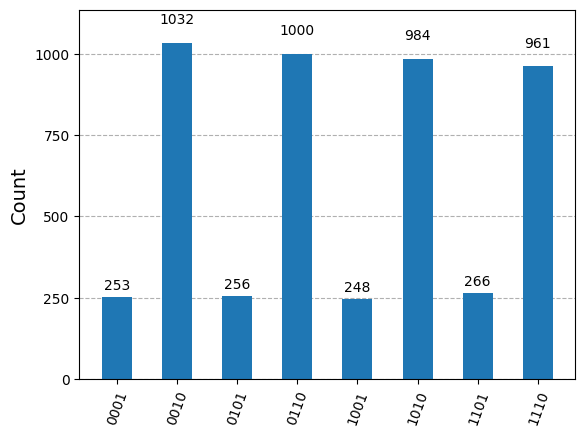

In [11]:
from qiskit.visualization import plot_histogram

backend_total = Aer.get_backend("qasm_simulator")
job = backend_total.run(transpile(total_circuit, backend=backend_total), shots=5000)
counts = job.result().get_counts()
plot_histogram(counts)

## 5. Compare against direct state preparation

The next cell tries a simpler baseline using Qiskit's `StatePreparation` primitive.


Its diagnostic role is useful: if direct state preparation behaves as expected while the custom qRAM route does not, the issue is likely in the angle derivation or in the hand-built circuit structure.

In [13]:
import numpy as np
from qiskit.circuit.library import StatePreparation

arr = [1.5, 0.5, 0.5, 1.5]
# arr = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 3]
# arr = [i for i in range(1,65)]

norm = np.linalg.norm(arr)
SP = StatePreparation(arr / norm)

num_qubits = int(np.sqrt(len(arr)))
qc = QuantumCircuit(num_qubits)

qc.append(SP, [i for i in range(num_qubits-1,-1,-1)])

job = backend.run(transpile(qc, backend=backend))

print(job.result().get_counts())
qc.decompose(reps=10).draw("text")


{np.str_('00'): np.float64(0.45), np.str_('01'): np.float64(0.05), np.str_('10'): np.float64(0.05), np.str_('11'): np.float64(0.45)}


┌────────────┐                                  
q_0: ────┤ U(π/2,0,0) ├──────■───────────────────────────
     ┌───┴────────────┴───┐┌─┴─┐┌───────────────────────┐
q_1: ┤ U(0.6435,-2π,-π/2) ├┤ X ├┤ U(0,0.75176,-0.75176) ├
     └────────────────────┘└───┘└───────────────────────┘

## 6. Probe an alternative evolution primitive

The final cell tests `PauliEvolutionGate` as a higher-level way to express matrix evolution.


This is best read as an exploratory comparison with the earlier `NumPyMatrix` route: it helps answer whether part of the original custom machinery could be replaced by a more native Qiskit primitive.

In [14]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp.from_operator(example_matrix)  # your Hamiltonian

# this is a gate you could append to a circuit, e.g. like
# my_circuit = QuantumCircuit(4)
# my_circuit.append(evo_gate, [0, 1, 2, 3])
evo_gate = PauliEvolutionGate(hamiltonian, time=1) 

# or we can just print the gate -- call .decompose() before .draw() 
# to see what's going on inside the blocks
evo_gate.definition.decompose(reps=4).draw("text")


global phase: 4.7832
   ┌───────────────┐
q: ┤ U(1,-π/2,π/2) ├
   └───────────────┘